Processing videos...
Processing video: video_only_ID_1.mp4
Processing video: video_only_ID_10.mp4
Processing video: video_only_ID_11.mp4
Processing video: video_only_ID_12.mp4
Processing video: video_only_ID_13.mp4
Processing video: video_only_ID_14.mp4
Processing video: video_only_ID_15.mp4
Processing video: video_only_ID_16.mp4
Processing video: video_only_ID_17.mp4
Processing video: video_only_ID_18.mp4
Processing video: video_only_ID_19.mp4
Processing video: video_only_ID_2.mp4
Processing video: video_only_ID_20.mp4
Processing video: video_only_ID_21.mp4
Processing video: video_only_ID_22.mp4
Processing video: video_only_ID_23.mp4
Processing video: video_only_ID_24.mp4
Processing video: video_only_ID_25.mp4
Processing video: video_only_ID_26.mp4
Processing video: video_only_ID_27.mp4
Processing video: video_only_ID_28.mp4
Processing video: video_only_ID_29.mp4
Processing video: video_only_ID_3.mp4
Processing video: video_only_ID_30.mp4
Processing video: video_only_ID_31.mp4
Process

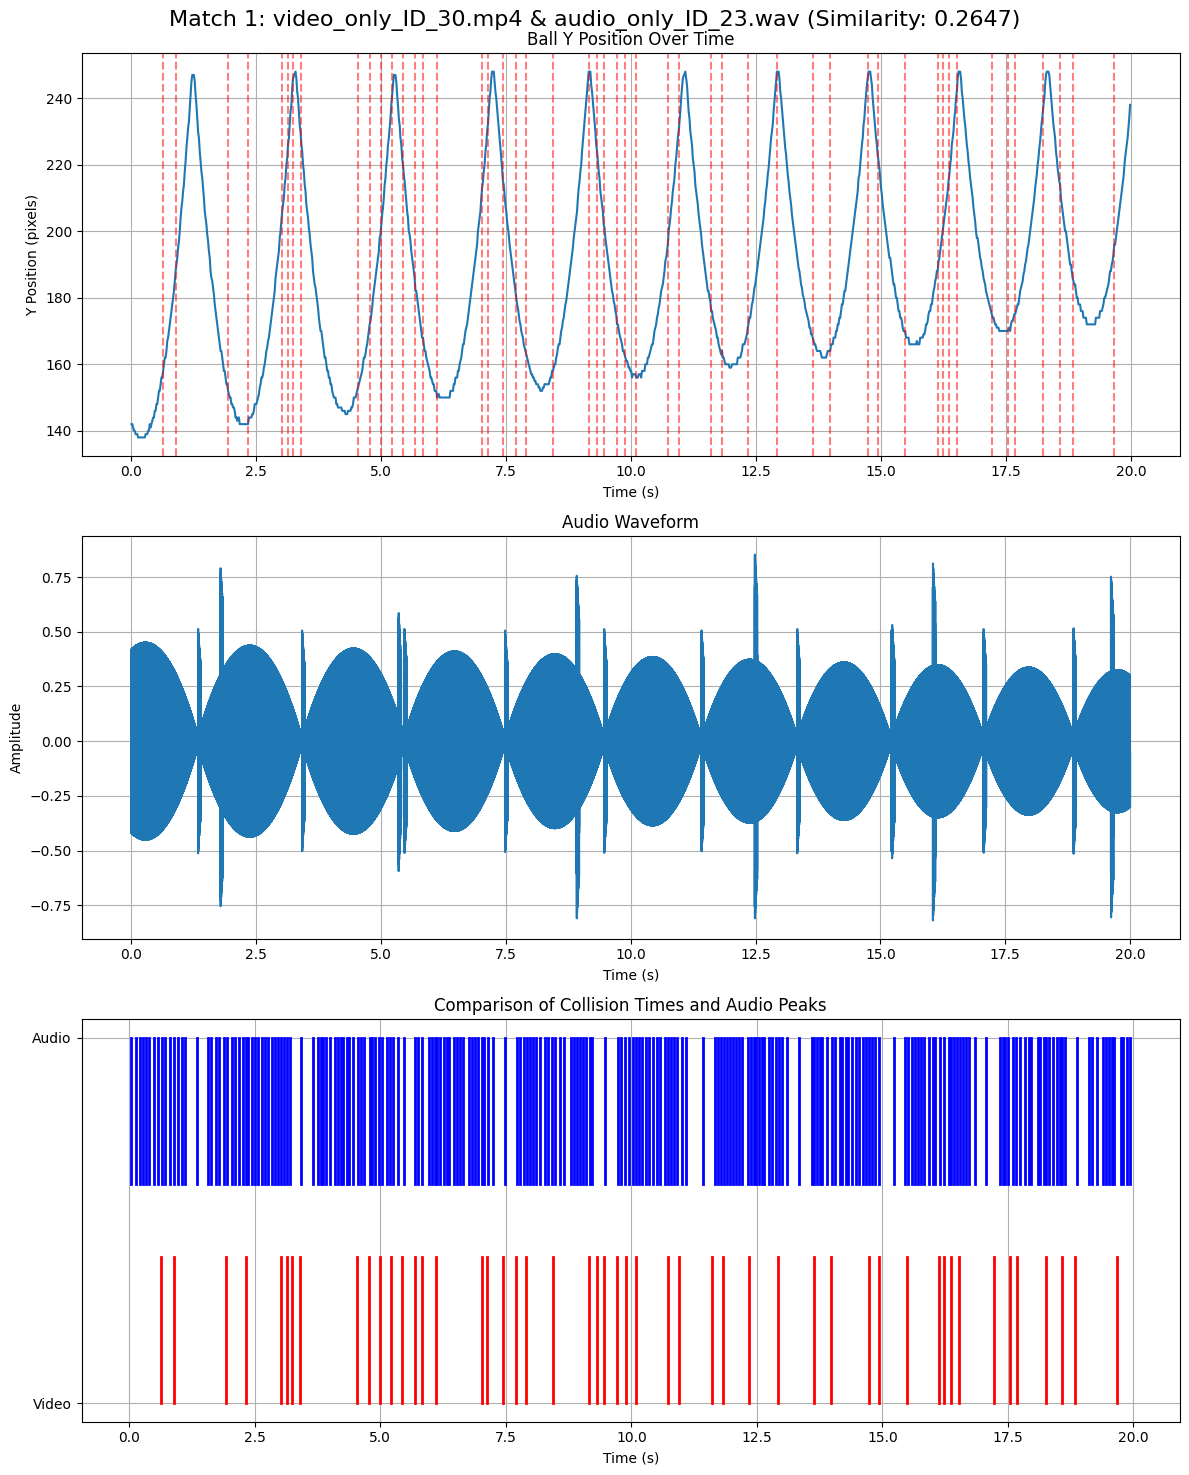

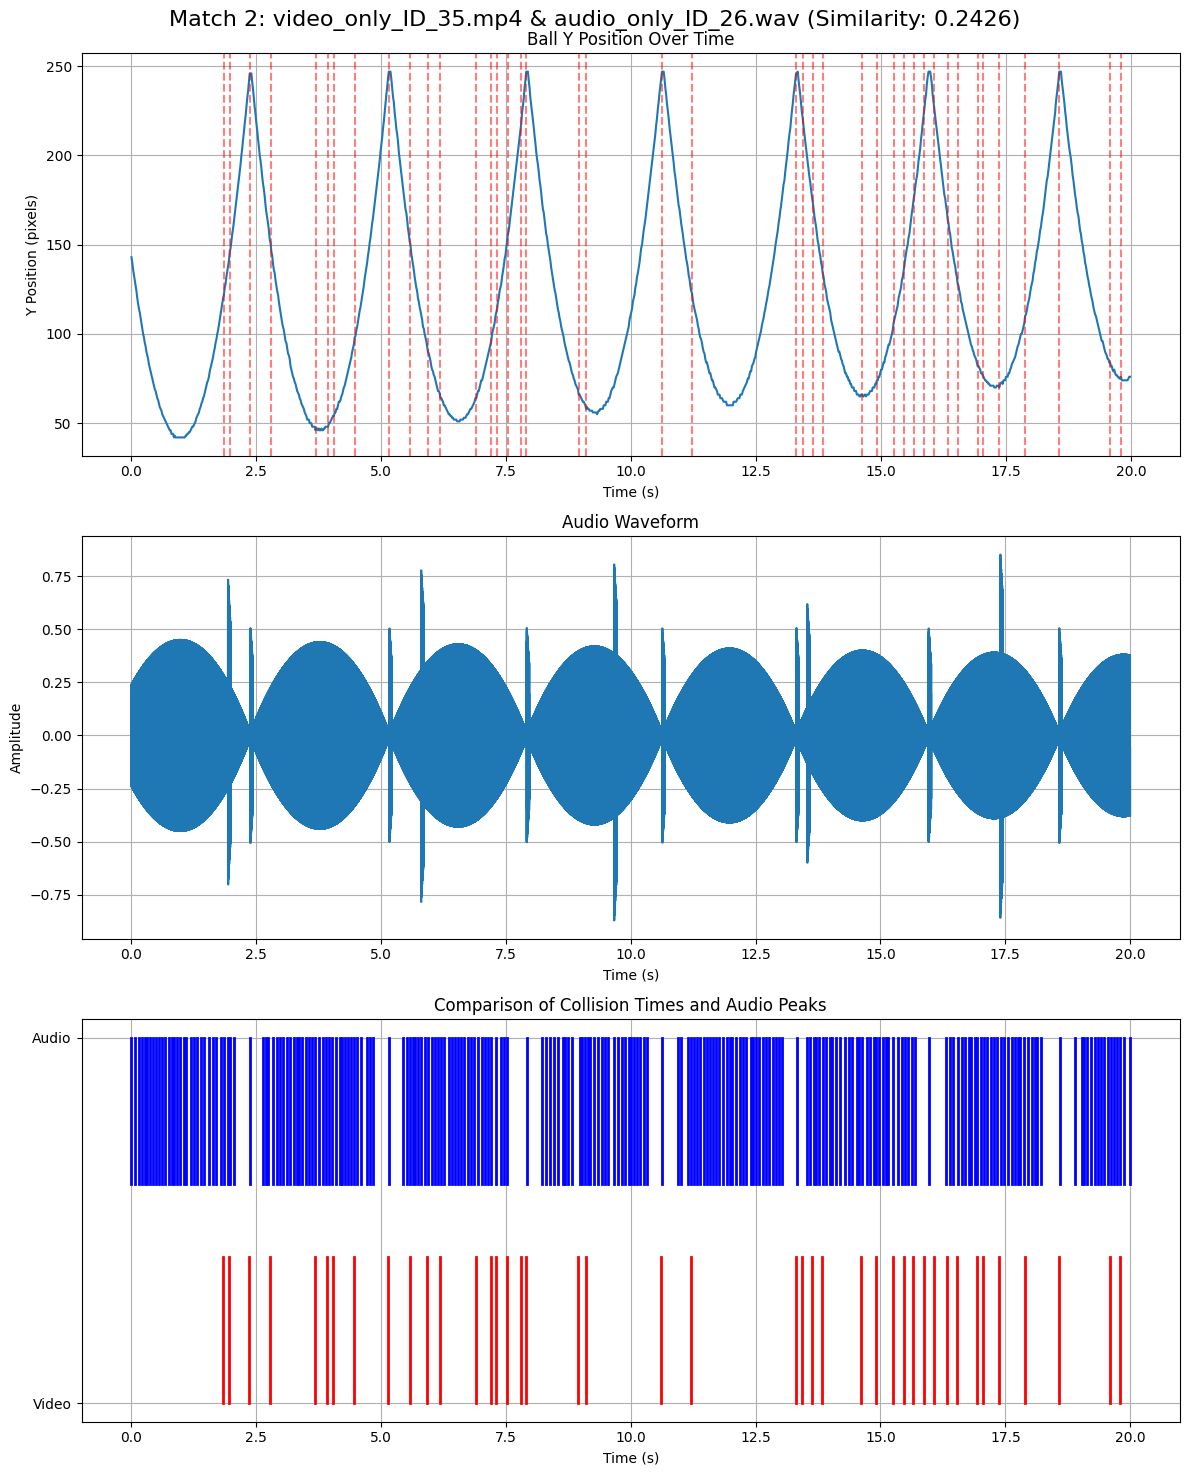

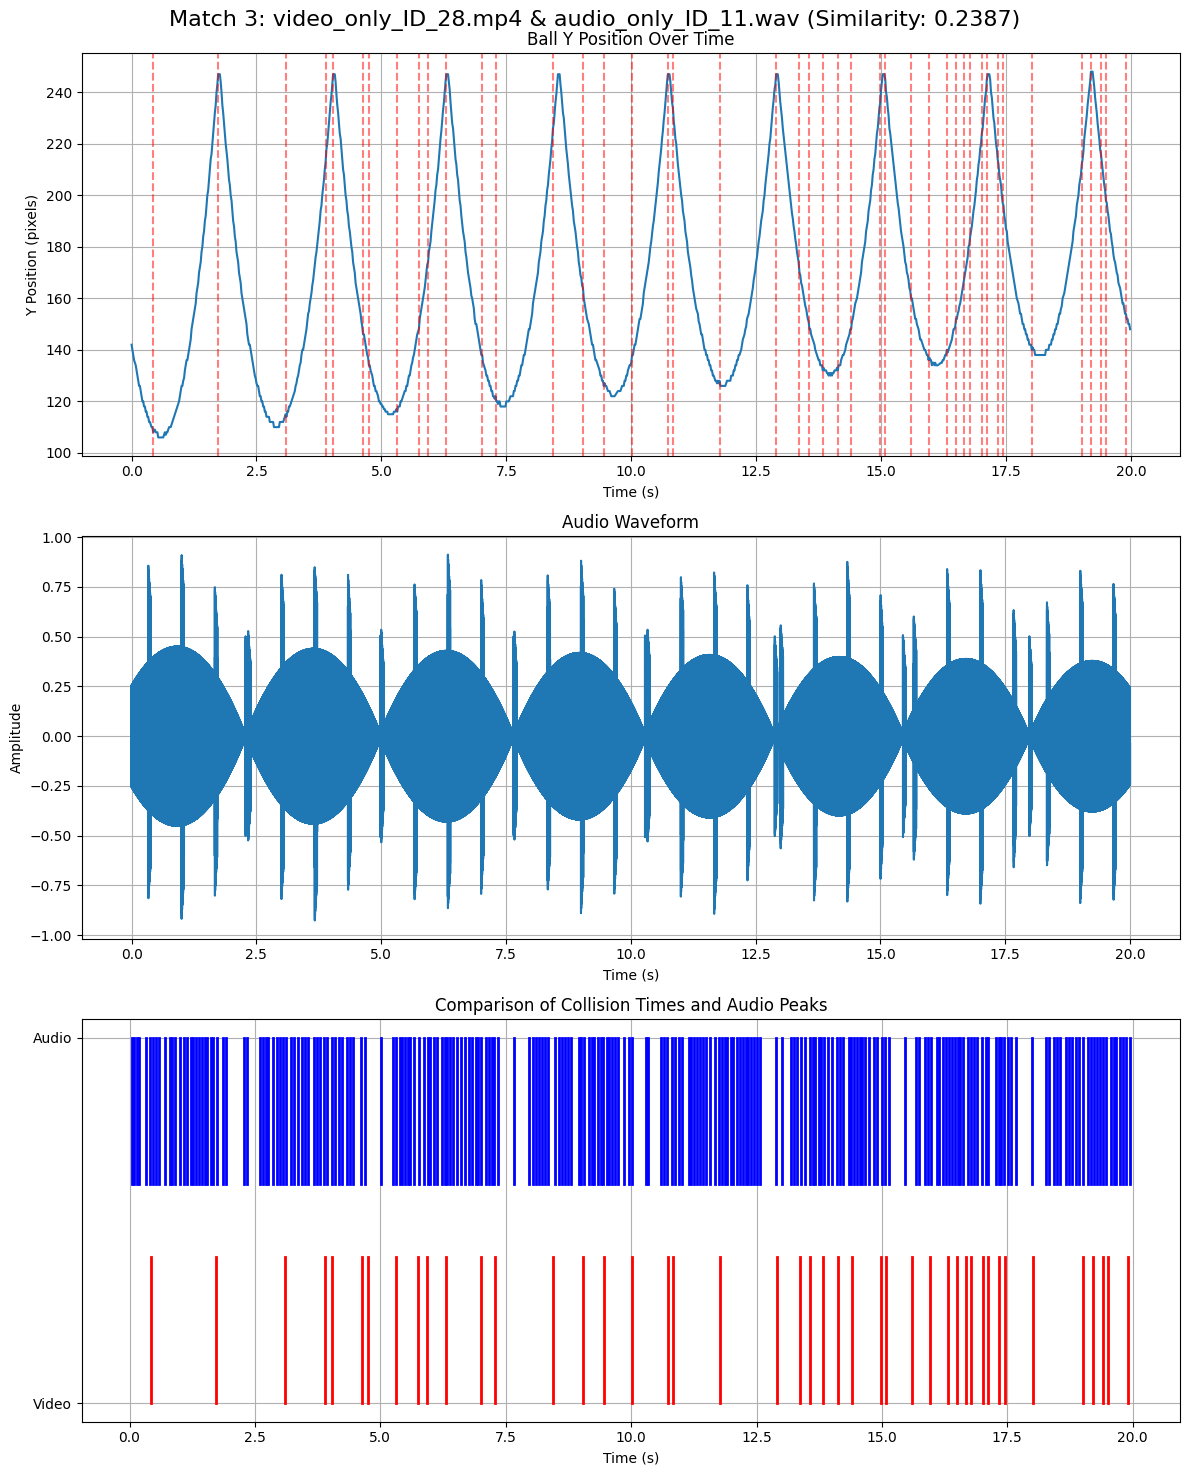

In [4]:
# Ball Motion and Audio Matching Notebook

# Import necessary libraries
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import find_peaks, savgol_filter
from scipy.spatial.distance import jaccard
from sklearn.metrics.pairwise import cosine_similarity
import librosa
import glob

# Set display options
plt.rcParams['figure.figsize'] = (12, 8)

# 1. Video Analysis Functions
def detect_ball_in_frame(frame):
    """Detect blue ball in a single frame using color thresholding"""
    # Convert frame to HSV color space
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    
    # Define range for blue color
    lower_blue = np.array([100, 50, 50])
    upper_blue = np.array([130, 255, 255])
    
    # Create a mask for blue color
    mask = cv2.inRange(hsv, lower_blue, upper_blue)
    
    # Find contours in the mask
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # If contours are found, get the largest one (assuming it's the ball)
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        if cv2.contourArea(largest_contour) > 50:  # Minimum area threshold
            M = cv2.moments(largest_contour)
            if M["m00"] != 0:
                cx = int(M["m10"] / M["m00"])
                cy = int(M["m01"] / M["m00"])
                return (cx, cy)
    
    return None

def analyze_video(video_path):
    """Analyze video to extract ball positions, velocities, and detect collisions"""
    cap = cv2.VideoCapture(video_path)
    
    # Get video properties
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Initialize lists to store data
    positions = []
    timestamps = []
    
    # Process each frame
    for frame_idx in range(frame_count):
        ret, frame = cap.read()
        if not ret:
            break
        
        timestamp = frame_idx / fps
        ball_pos = detect_ball_in_frame(frame)
        
        if ball_pos:
            positions.append(ball_pos)
            timestamps.append(timestamp)
    
    cap.release()
    
    # Convert to numpy arrays
    positions = np.array(positions)
    timestamps = np.array(timestamps)
    
    if len(positions) < 3:
        return {
            'video_path': video_path,
            'positions': positions,
            'timestamps': timestamps,
            'velocities': np.array([]),
            'accelerations': np.array([]),
            'collision_times': np.array([])
        }
    
    # Calculate velocities (difference of positions)
    velocities = np.diff(positions, axis=0) / np.diff(timestamps)[:, np.newaxis]
    
    # Calculate accelerations (difference of velocities)
    accelerations = np.diff(velocities, axis=0) / np.diff(timestamps[:-1])[:, np.newaxis]
    
    # Detect collisions based on acceleration spikes
    acc_magnitudes = np.linalg.norm(accelerations, axis=1)
    acc_threshold = np.percentile(acc_magnitudes, 95)  # Adaptive threshold
    collision_indices = np.where(acc_magnitudes > acc_threshold)[0]
    
    # Convert collision indices to timestamps
    collision_times = timestamps[1:-1][collision_indices]
    
    # Ensure collisions are not too close (minimum time between collisions)
    min_time_between_collisions = 0.1  # 100 ms
    filtered_collision_times = []
    
    if len(collision_times) > 0:
        filtered_collision_times.append(collision_times[0])
        for i in range(1, len(collision_times)):
            if collision_times[i] - filtered_collision_times[-1] > min_time_between_collisions:
                filtered_collision_times.append(collision_times[i])
    
    collision_times = np.array(filtered_collision_times)
    
    return {
        'video_path': video_path,
        'positions': positions,
        'timestamps': timestamps,
        'velocities': velocities,
        'accelerations': accelerations,
        'collision_times': collision_times
    }

def visualize_video_analysis(video_data, title=None):
    """Visualize the video analysis results"""
    fig, axs = plt.subplots(3, 1, figsize=(12, 15))
    
    # Plot positions
    if len(video_data['positions']) > 0:
        axs[0].plot(video_data['timestamps'], video_data['positions'][:, 0], label='X Position')
        axs[0].plot(video_data['timestamps'], video_data['positions'][:, 1], label='Y Position')
        axs[0].set_title('Ball Position Over Time')
        axs[0].set_xlabel('Time (s)')
        axs[0].set_ylabel('Position (pixels)')
        axs[0].legend()
        axs[0].grid(True)
    
    # Plot velocities
    if len(video_data['velocities']) > 0:
        vel_timestamps = video_data['timestamps'][1:]
        axs[1].plot(vel_timestamps, video_data['velocities'][:, 0], label='X Velocity')
        axs[1].plot(vel_timestamps, video_data['velocities'][:, 1], label='Y Velocity')
        axs[1].set_title('Ball Velocity Over Time')
        axs[1].set_xlabel('Time (s)')
        axs[1].set_ylabel('Velocity (pixels/s)')
        axs[1].legend()
        axs[1].grid(True)
    
    # Plot accelerations and collisions
    if len(video_data['accelerations']) > 0:
        acc_timestamps = video_data['timestamps'][1:-1]
        acc_magnitudes = np.linalg.norm(video_data['accelerations'], axis=1)
        axs[2].plot(acc_timestamps, acc_magnitudes, label='Acceleration Magnitude')
        
        # Mark collisions
        for col_time in video_data['collision_times']:
            axs[2].axvline(x=col_time, color='r', linestyle='--', alpha=0.5)
        
        axs[2].set_title('Ball Acceleration and Collisions')
        axs[2].set_xlabel('Time (s)')
        axs[2].set_ylabel('Acceleration Magnitude')
        axs[2].legend()
        axs[2].grid(True)
    
    if title:
        fig.suptitle(title, fontsize=16)
    
    plt.tight_layout()
    return fig

# 2. Audio Analysis Functions
def analyze_audio(audio_path):
    """Analyze audio file to detect beeps/collisions"""
    # Load audio file
    y, sr = librosa.load(audio_path, sr=None)
    
    # Calculate duration
    duration = len(y) / sr
    
    # Calculate envelope
    envelope = np.abs(y)
    
    # Apply smoothing to the envelope
    window_size = int(0.01 * sr)  # 10ms window
    smoothed_envelope = np.convolve(envelope, np.ones(window_size)/window_size, mode='same')
    
    # Find peaks in the envelope
    peaks, _ = find_peaks(smoothed_envelope, height=0.1, distance=int(0.05 * sr))  # Minimum distance 50ms
    
    # Convert peak indices to timestamps
    peak_times = peaks / sr
    
    return {
        'audio_path': audio_path,
        'signal': y,
        'sample_rate': sr,
        'envelope': envelope,
        'smoothed_envelope': smoothed_envelope,
        'peak_times': peak_times,
        'duration': duration
    }

def visualize_audio_analysis(audio_data, title=None):
    """Visualize the audio analysis results"""
    fig, axs = plt.subplots(2, 1, figsize=(12, 10))
    
    # Time axis
    time = np.linspace(0, audio_data['duration'], len(audio_data['signal']))
    
    # Plot waveform
    axs[0].plot(time, audio_data['signal'])
    axs[0].set_title('Audio Waveform')
    axs[0].set_xlabel('Time (s)')
    axs[0].set_ylabel('Amplitude')
    axs[0].grid(True)
    
    # Plot envelope and peaks
    axs[1].plot(time, audio_data['smoothed_envelope'])
    axs[1].plot(audio_data['peak_times'], audio_data['smoothed_envelope'][audio_data['peak_times'] * audio_data['sample_rate'].astype(int)], 'rx')
    
    # Mark peaks
    for peak_time in audio_data['peak_times']:
        axs[1].axvline(x=peak_time, color='r', linestyle='--', alpha=0.5)
    
    axs[1].set_title('Audio Envelope and Detected Peaks')
    axs[1].set_xlabel('Time (s)')
    axs[1].set_ylabel('Envelope')
    axs[1].grid(True)
    
    if title:
        fig.suptitle(title, fontsize=16)
    
    plt.tight_layout()
    return fig

# 3. Matching Functions
def calculate_similarity(video_data, audio_data, tolerance=0.05):
    """Calculate similarity between video collision times and audio peak times"""
    video_collisions = video_data['collision_times']
    audio_peaks = audio_data['peak_times']
    
    if len(video_collisions) == 0 or len(audio_peaks) == 0:
        return 0
    
    # Create binary vectors for video collisions and audio peaks
    max_time = max(video_collisions[-1] if len(video_collisions) > 0 else 0, 
                   audio_peaks[-1] if len(audio_peaks) > 0 else 0)
    
    # Add a small buffer to max_time
    max_time += 1
    
    # Create time bins
    bins = np.arange(0, max_time + tolerance, tolerance)
    
    # Create binary vectors
    video_vector = np.zeros(len(bins)-1)
    audio_vector = np.zeros(len(bins)-1)
    
    # Fill vectors
    for collision in video_collisions:
        bin_idx = int(collision / tolerance)
        if bin_idx < len(video_vector):
            video_vector[bin_idx] = 1
    
    for peak in audio_peaks:
        bin_idx = int(peak / tolerance)
        if bin_idx < len(audio_vector):
            audio_vector[bin_idx] = 1
    
    # Calculate Jaccard similarity
    intersection = np.sum(np.logical_and(video_vector, audio_vector))
    union = np.sum(np.logical_or(video_vector, audio_vector))
    
    jaccard_sim = intersection / union if union > 0 else 0
    
    # Calculate cosine similarity
    cos_sim = cosine_similarity([video_vector], [audio_vector])[0][0]
    
    # Combine similarities
    combined_sim = (jaccard_sim + cos_sim) / 2
    
    return combined_sim

def match_audio_to_videos(video_analyses, audio_analyses, tolerance=0.05):
    """Match audio files to video files based on similarity"""
    similarities = []
    
    for audio_idx, audio_data in enumerate(audio_analyses):
        audio_path = audio_data['audio_path']
        audio_id = os.path.basename(audio_path).split('_')[2]  # Extract ID from audio filename
        
        for video_idx, video_data in enumerate(video_analyses):
            video_path = video_data['video_path']
            video_id = os.path.basename(video_path).split('_')[2]  # Extract ID from video filename
            
            similarity = calculate_similarity(video_data, audio_data, tolerance)
            
            similarities.append({
                'audio_path': audio_path,
                'audio_id': audio_id,
                'video_path': video_path,
                'video_id': video_id,
                'similarity': similarity
            })
    
    # Convert to DataFrame
    similarities_df = pd.DataFrame(similarities)
    
    # Sort by similarity in descending order
    similarities_df = similarities_df.sort_values('similarity', ascending=False)
    
    return similarities_df

def create_matches(similarities_df):
    """Create final matches based on highest similarity"""
    # Sort by similarity in descending order
    sorted_df = similarities_df.sort_values('similarity', ascending=False)
    
    # Initialize sets to keep track of matched audio and video files
    matched_audio = set()
    matched_video = set()
    
    # Initialize list to store final matches
    final_matches = []
    
    # Iterate through sorted similarities
    for _, row in sorted_df.iterrows():
        audio_path = row['audio_path']
        video_path = row['video_path']
        
        # Check if audio or video has already been matched
        if audio_path not in matched_audio and video_path not in matched_video:
            matched_audio.add(audio_path)
            matched_video.add(video_path)
            
            final_matches.append({
                'audio_path': audio_path,
                'video_path': video_path,
                'similarity': row['similarity']
            })
    
    # Convert to DataFrame
    matches_df = pd.DataFrame(final_matches)
    
    return matches_df

# 4. Main Functions
def process_all_videos(video_dir):
    """Process all videos in the directory"""
    video_files = glob.glob(os.path.join(video_dir, '*.mp4'))
    video_analyses = []
    
    for video_path in video_files:
        print(f"Processing video: {os.path.basename(video_path)}")
        video_data = analyze_video(video_path)
        video_analyses.append(video_data)
    
    return video_analyses

def process_all_audio(audio_dir):
    """Process all audio files in the directory"""
    audio_files = glob.glob(os.path.join(audio_dir, '*.wav'))
    audio_analyses = []
    
    for audio_path in audio_files:
        print(f"Processing audio: {os.path.basename(audio_path)}")
        audio_data = analyze_audio(audio_path)
        audio_analyses.append(audio_data)
    
    return audio_analyses

def main(video_dir='video_only', audio_dir='audio_only', output_csv='matches.csv'):
    """Main function to process all files and create matches"""
    print("Processing videos...")
    video_analyses = process_all_videos(video_dir)
    
    print("Processing audio files...")
    audio_analyses = process_all_audio(audio_dir)
    
    print("Matching audio to videos...")
    similarities_df = match_audio_to_videos(video_analyses, audio_analyses)
    
    print("Creating final matches...")
    matches_df = create_matches(similarities_df)

   
    # Prepare output CSV
    output_df = matches_df[['audio_path', 'video_path']]
    output_df['audio_id'] = output_df['audio_path'].apply(lambda x: os.path.basename(x).split('_')[2])
    output_df['video_id'] = output_df['video_path'].apply(lambda x: os.path.basename(x).split('_')[2])
    
    # Create final CSV with just file IDs
    final_df = pd.DataFrame({
        'audio_file': output_df['audio_path'].apply(os.path.basename),
        'video_file': output_df['video_path'].apply(os.path.basename)
    })
    
    # Save to CSV
    final_df.to_csv(output_csv, index=False)
    print(f"Matches saved to {output_csv}")
    
    return {
        'video_analyses': video_analyses,
        'audio_analyses': audio_analyses,
        'similarities': similarities_df,
        'matches': matches_df,
        'final_df': final_df
    }

# 5. Visualization and Debugging Functions
def visualize_match(video_data, audio_data, similarity, title=None):
    """Visualize a matched pair of video and audio"""
    fig, axs = plt.subplots(3, 1, figsize=(12, 15))
    
    # Plot ball y-position
    if len(video_data['positions']) > 0:
        axs[0].plot(video_data['timestamps'], video_data['positions'][:, 1], label='Y Position')
        axs[0].set_title('Ball Y Position Over Time')
        axs[0].set_xlabel('Time (s)')
        axs[0].set_ylabel('Y Position (pixels)')
        axs[0].grid(True)
        
        # Mark video collisions
        for col_time in video_data['collision_times']:
            axs[0].axvline(x=col_time, color='r', linestyle='--', alpha=0.5)
    
    # Plot audio waveform
    time = np.linspace(0, audio_data['duration'], len(audio_data['signal']))
    axs[1].plot(time, audio_data['signal'])
    axs[1].set_title('Audio Waveform')
    axs[1].set_xlabel('Time (s)')
    axs[1].set_ylabel('Amplitude')
    axs[1].grid(True)
    
    # Plot comparison of collision times and audio peaks
    axs[2].set_title('Comparison of Collision Times and Audio Peaks')
    axs[2].set_xlabel('Time (s)')
    axs[2].set_yticks([0, 1])
    axs[2].set_yticklabels(['Video', 'Audio'])
    axs[2].grid(True)
    
    # Plot video collisions
    for col_time in video_data['collision_times']:
        axs[2].plot([col_time, col_time], [0, 0.4], 'r-', linewidth=2)
    
    # Plot audio peaks
    for peak_time in audio_data['peak_times']:
        axs[2].plot([peak_time, peak_time], [0.6, 1], 'b-', linewidth=2)
    
    if title:
        fig.suptitle(f"{title} (Similarity: {similarity:.4f})", fontsize=16)
    
    plt.tight_layout()
    return fig

def evaluate_matches(matches_df, video_analyses, audio_analyses):
    """Evaluate the quality of matches"""
    match_details = []
    
    for _, row in matches_df.iterrows():
        audio_path = row['audio_path']
        video_path = row['video_path']
        similarity = row['similarity']
        
        # Find corresponding analyses
        video_data = next((v for v in video_analyses if v['video_path'] == video_path), None)
        audio_data = next((a for a in audio_analyses if a['audio_path'] == audio_path), None)
        
        if video_data and audio_data:
            # Count collisions and peaks
            num_video_collisions = len(video_data['collision_times'])
            num_audio_peaks = len(audio_data['peak_times'])
            
            match_details.append({
                'audio_file': os.path.basename(audio_path),
                'video_file': os.path.basename(video_path),
                'similarity': similarity,
                'video_collisions': num_video_collisions,
                'audio_peaks': num_audio_peaks,
                'collision_diff': abs(num_video_collisions - num_audio_peaks)
            })
    
    match_details_df = pd.DataFrame(match_details)
    return match_details_df

# Example usage
if __name__ == "__main__":
    # Define directories
    video_dir = 'video_only'
    audio_dir = 'audio_only'
    output_csv = 'matches.csv'
    
    # Run main function
    results = main(video_dir, audio_dir, output_csv)
    
    # Print summary
    print(f"Processed {len(results['video_analyses'])} videos and {len(results['audio_analyses'])} audio files")
    print(f"Created {len(results['matches'])} matches")
    
    # Evaluate matches
    match_details = evaluate_matches(results['matches'], results['video_analyses'], results['audio_analyses'])
    print("\nMatch Details:")
    print(match_details.sort_values('similarity', ascending=False).head(10))
    
    # Visualize top matches
    top_matches = results['matches'].head(3)
    for idx, row in top_matches.iterrows():
        audio_path = row['audio_path']
        video_path = row['video_path']
        similarity = row['similarity']
        
        # Find corresponding analyses
        video_data = next((v for v in results['video_analyses'] if v['video_path'] == video_path), None)
        audio_data = next((a for a in results['audio_analyses'] if a['audio_path'] == audio_path), None)
        
        if video_data and audio_data:
            title = f"Match {idx+1}: {os.path.basename(video_path)} & {os.path.basename(audio_path)}"
            visualize_match(video_data, audio_data, similarity, title)
            plt.show()


In [10]:
!pip install moviepy==1.0.3

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for moviepy: filename=moviepy-1.0.3-py3-none-any.whl size=110804 sha256=f2ec56f2496c6c674f406ecaf28640b2fb0db50cc0135f1e2db7fcd6178de4ff
  Stored in directory: c:\users\amuaa\appdata\local\pip\cache\wheels\ee\0c\ac\4c0c65f1289060c39182ba74294d8b72d03600d619663e8935
Successfully built moviepy
  Attempting uninstall: decorator
    Found existing installation: decorator 5.2.1
    Uninstalling decorator-5.2.1:
      Successfully uninstalled decorator-5.2.1
  Attempting uninstall: moviepy
    Found existing installation: moviepy 2.1.2
    Uninstalling moviepy-2.1.2:
      Successfully uninstalled moviepy-2.1.2



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
matches_df


,audio_path,video_path,similarity
0,audio_only\audio_only_ID_23.wav,video_only\video_only_ID_30.mp4,0.264698
1,audio_only\audio_only_ID_26.wav,video_only\video_only_ID_35.mp4,0.242591
2,audio_only\audio_only_ID_11.wav,video_only\video_only_ID_28.mp4,0.238687
3,audio_only\audio_only_ID_37.wav,video_only\video_only_ID_15.mp4,0.235294
4,audio_only\audio_only_ID_42.wav,video_only\video_only_ID_5.mp4,0.231712
5,audio_only\audio_only_ID_4.wav,video_only\video_only_ID_7.mp4,0.229847
6,audio_only\audio_only_ID_39.wav,video_only\video_only_ID_40.mp4,0.228903
7,audio_only\audio_only_ID_38.wav,video_only\video_only_ID_20.mp4,0.227504
8,audio_only\audio_only_ID_31.wav,video_only\video_only_ID_4.mp4,0.227175
9,audio_only\audio_only_ID_5.wav,video_only\video_only_ID_22.mp4,0.226423


In [13]:
# Final version: Combine video and audio for validation

import os
import pandas as pd
from tqdm import tqdm
from moviepy.editor import VideoFileClip, AudioFileClip

def combine_video_audio_moviepy(video_path, audio_path, output_path):
    """
    Combine a video and audio file using moviepy - final working version
    """
    try:
        # Load video and audio
        video_clip = VideoFileClip(video_path)
        audio_clip = AudioFileClip(audio_path)
        
        # Make sure audio doesn't exceed video length
        if audio_clip.duration > video_clip.duration:
            # Trim audio to match video duration directly when adding it
            video_with_audio = video_clip.set_audio(audio_clip.set_duration(video_clip.duration))
        else:
            # Use audio as is
            video_with_audio = video_clip.set_audio(audio_clip)
        
        # Write the result to a file with minimal output
        video_with_audio.write_videofile(
            output_path, 
            codec='libx264', 
            audio_codec='aac', 
            verbose=False, 
            logger=None
        )
        
        # Close clips to free resources
        video_clip.close()
        audio_clip.close()
        video_with_audio.close()
        
        return True
    except Exception as e:
        print(f"Error combining video and audio for {os.path.basename(video_path)}: {e}")
        return False

def create_validation_videos(matches_df, output_dir='validation_videos'):
    """
    Create validation videos for matches
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Process each match
    combined_count = 0
    errors = []
    
    for idx, row in tqdm(matches_df.iterrows(), total=len(matches_df), desc="Creating validation videos"):
        # Get video and audio file paths
        video_path = row['video_path']
        audio_path = row['audio_path']
        
        # Create output filename
        video_id = os.path.basename(video_path).split('.')[0]
        audio_id = os.path.basename(audio_path).split('.')[0]
        output_filename = f"validation_{video_id}_with_{audio_id}.mp4"
        output_path = os.path.join(output_dir, output_filename)
        
        # Combine video and audio
        success = combine_video_audio_moviepy(video_path, audio_path, output_path)
        if success:
            combined_count += 1
        else:
            errors.append((video_path, audio_path))
    
    print(f"Created {combined_count} validation videos in {output_dir}")
    
    if errors:
        print(f"Failed to create {len(errors)} videos")
        for v, a in errors[:5]:  # Show first 5 errors only
            print(f"  - {os.path.basename(v)} + {os.path.basename(a)}")
        if len(errors) > 5:
            print(f"  ... and {len(errors) - 5} more")
    
    return combined_count

# Function to create a subset of matches for validation
def create_validation_subset(matches_df, num_samples=5):
    """Create a subset of matches for validation"""
    # Sort by similarity
    if 'similarity' in matches_df.columns:
        sorted_df = matches_df.sort_values('similarity', ascending=False)
        
        # Calculate positions for sampling
        total = len(sorted_df)
        indices = []
        
        # Get top, middle and bottom samples
        if num_samples >= 3:
            # At least one from top, middle, and bottom
            top_n = max(1, num_samples // 3)
            bottom_n = max(1, num_samples // 3)
            middle_n = num_samples - top_n - bottom_n
            
            # Top matches
            indices.extend(range(top_n))
            
            # Middle matches
            mid_start = total // 2 - middle_n // 2
            indices.extend(range(mid_start, mid_start + middle_n))
            
            # Bottom matches
            indices.extend(range(total - bottom_n, total))
        else:
            # Just take the first few
            indices.extend(range(min(num_samples, total)))
            
        # Get the rows at these indices
        subset = sorted_df.iloc[indices]
    else:
        # No similarity column, just take first n
        subset = matches_df.head(num_samples)
    
    return subset

# Run validation
def validate_matches(matches_df=None, num_samples=5):
    """Create validation videos for a subset of matches"""
    if matches_df is None:
        # Try to load matches
        try:
            # First try to load from CSV
            matches_df = pd.read_csv('matches.csv')
            print(f"Loaded {len(matches_df)} matches from CSV")
            
            # Add full paths if not present
            if 'audio_path' not in matches_df.columns:
                matches_df['audio_path'] = matches_df['audio_file'].apply(lambda x: os.path.join('audio_only', x))
            if 'video_path' not in matches_df.columns:
                matches_df['video_path'] = matches_df['video_file'].apply(lambda x: os.path.join('video_only', x))
                
        except Exception as e:
            print(f"Error loading matches from CSV: {e}")
            print("No matches found. Please run the matching algorithm first.")
            return None
    
    # Create validation subset
    validation_subset = create_validation_subset(matches_df, num_samples)
    
    # Create validation videos
    create_validation_videos(validation_subset)
    
    print("\nValidation subset details:")
    for idx, row in validation_subset.iterrows():
        video_file = os.path.basename(row['video_path'])
        audio_file = os.path.basename(row['audio_path'])
        sim = row.get('similarity', 'N/A')
        print(f"Match {idx}: Video={video_file}, Audio={audio_file}, Similarity={sim}")
    
    return validation_subset

# Function to validate all matches
def validate_all_matches(matches_df=None):
    """Create validation videos for all matches"""
    if matches_df is None:
        # Try to load matches
        try:
            # First try to load from CSV
            matches_df = pd.read_csv('matches.csv')
            print(f"Loaded {len(matches_df)} matches from CSV")
            
            # Add full paths if not present
            if 'audio_path' not in matches_df.columns:
                matches_df['audio_path'] = matches_df['audio_file'].apply(lambda x: os.path.join('audio_only', x))
            if 'video_path' not in matches_df.columns:
                matches_df['video_path'] = matches_df['video_file'].apply(lambda x: os.path.join('video_only', x))
                
        except Exception as e:
            print(f"Error loading matches from CSV: {e}")
            print("No matches found. Please run the matching algorithm first.")
            return None
    
    # Create validation videos
    create_validation_videos(matches_df)
    
    return matches_df

# Example usage
if __name__ == "__main__":
    # Try to load matches from previous analysis
    results = globals().get('results', None)
    matches_df = None
    
    if results and 'matches' in results:
        matches_df = results['matches']
        print(f"Using {len(matches_df)} matches from previous analysis")
    else:
        try:
            # Try to load from CSV
            matches_df = pd.read_csv('matches.csv')
            print(f"Loaded {len(matches_df)} matches from CSV")
            
            # Add full paths if not present
            if 'audio_path' not in matches_df.columns:
                matches_df['audio_path'] = matches_df['audio_file'].apply(lambda x: os.path.join('audio_only', x))
            if 'video_path' not in matches_df.columns:
                matches_df['video_path'] = matches_df['video_file'].apply(lambda x: os.path.join('video_only', x))
                
        except Exception as e:
            print(f"Error loading matches: {e}")
            print("No previous matches found. Please run the matching algorithm first.")
    
    if matches_df is not None:
        # First, validate a small subset
        num_to_validate = min(5, len(matches_df))
        print(f"\nCreating validation videos for {num_to_validate} sample matches...")
        validation_subset = validate_matches(matches_df, num_samples=num_to_validate)
        
        # Ask if user wants to validate all
        if len(matches_df) > num_to_validate:
            validate_all = input(f"\nDo you want to create validation videos for all {len(matches_df)} matches? (y/n): ")
            if validate_all.lower() == 'y':
                print("\nCreating validation videos for all matches...")
                validate_all_matches(matches_df)

TypeError: deprecated_version_of() got an unexpected keyword argument 'oldname'. Did you mean 'old_name'?